# Decision Tree


In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [97]:
df = pd.read_csv("salaries.csv")
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [98]:
input = df.drop(["salary_more_then_100k"], axis="columns")
input.head()

,company,job,degree
0,google,sales executive,bachelors
1,google,sales executive,masters
2,google,business manager,bachelors
3,google,business manager,masters
4,google,computer programmer,bachelors


In [99]:
company_label = LabelEncoder()
job_label = LabelEncoder()
degree_label = LabelEncoder()

input["company_label"] = company_label.fit_transform(input.company)
input["job_label"] = job_label.fit_transform(input.job)
input["degree_label"] = degree_label.fit_transform(input.degree)
input

,company,job,degree,company_label,job_label,degree_label
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0
5,google,computer programmer,masters,2,1,1
6,abc pharma,sales executive,masters,0,2,1
7,abc pharma,computer programmer,bachelors,0,1,0
8,abc pharma,business manager,bachelors,0,0,0
9,abc pharma,business manager,masters,0,0,1


In [100]:
# Company : 0 -> abc pharma, 1 -> facebook, 2 -> google
# Job : 0 -> business manager, 1 -> computer programmer, 2 -> sales executive
# Degree : 0 -> bachelors, 1 -> masters

data = input.drop(["company", "job", "degree"], axis="columns")
target = df["salary_more_then_100k"]

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.2, random_state=10
)

In [101]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [102]:
model.score(X_test, y_test)

0.75

In [103]:
model.predict(X_test)

array([0, 1, 1, 0])

In [104]:
y_test

5     1
3     1
14    1
7     0
Name: salary_more_then_100k, dtype: int64

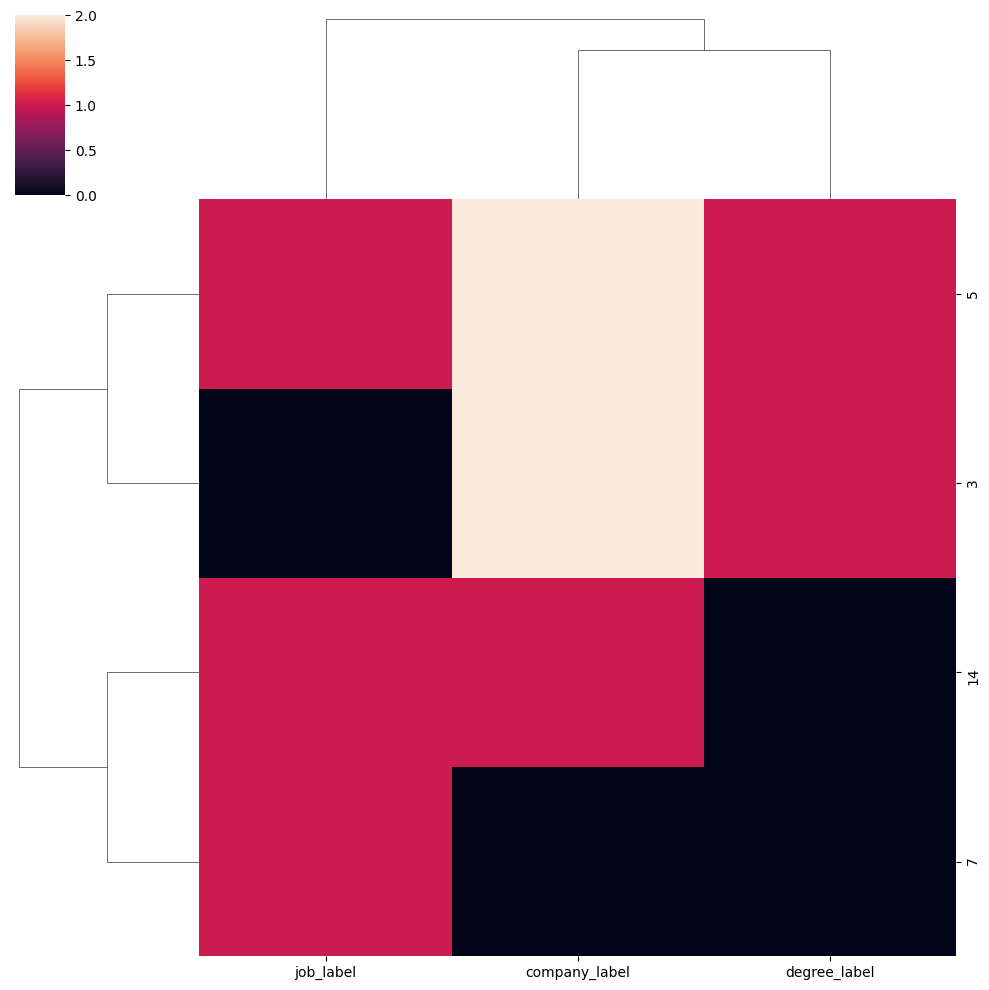

In [ ]:
import seaborn as sn

sn.clustermap(X_test)

## Decision Tree Model on Titanic Data


In [107]:
titanic = pd.read_csv(
    "F:\\Downloads\\titanic.csv", usecols=["Survived", "Pclass", "Sex", "Age", "Fare"]
)
titanic.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [108]:
len(titanic)

891

In [109]:
input = titanic.drop("Survived", axis="columns")
target = titanic.Survived

In [110]:
from sklearn.preprocessing import LabelEncoder

Sex_label = LabelEncoder()
input.Sex = Sex_label.fit_transform(input.Sex)
input.head()

,Pclass,Sex,Age,Fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


In [111]:
input.Age = input.Age.fillna(input.Age.median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    input, target, test_size=0.2, random_state=5
)
print(len(X_test))
print(len(X_train))

179
712


In [127]:
from sklearn.tree import DecisionTreeClassifier

titanic_model = DecisionTreeClassifier()
titanic_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
titanic_model.score(X_test, y_test)

0.7988826815642458

In [125]:
from sklearn.metrics import confusion_matrix

y_predict = titanic_model.predict(X_test)
cm = confusion_matrix(y_test, y_predict)

<Axes: >

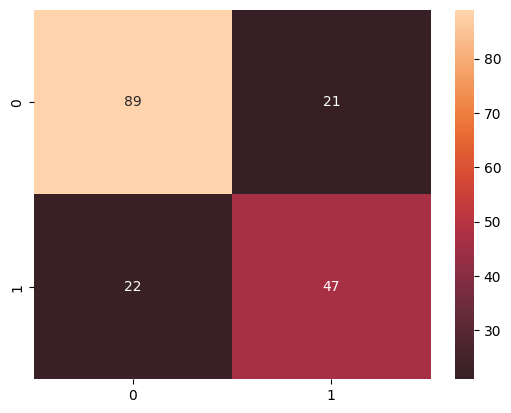

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn

sn.heatmap(cm, annot=True, center=11.2)

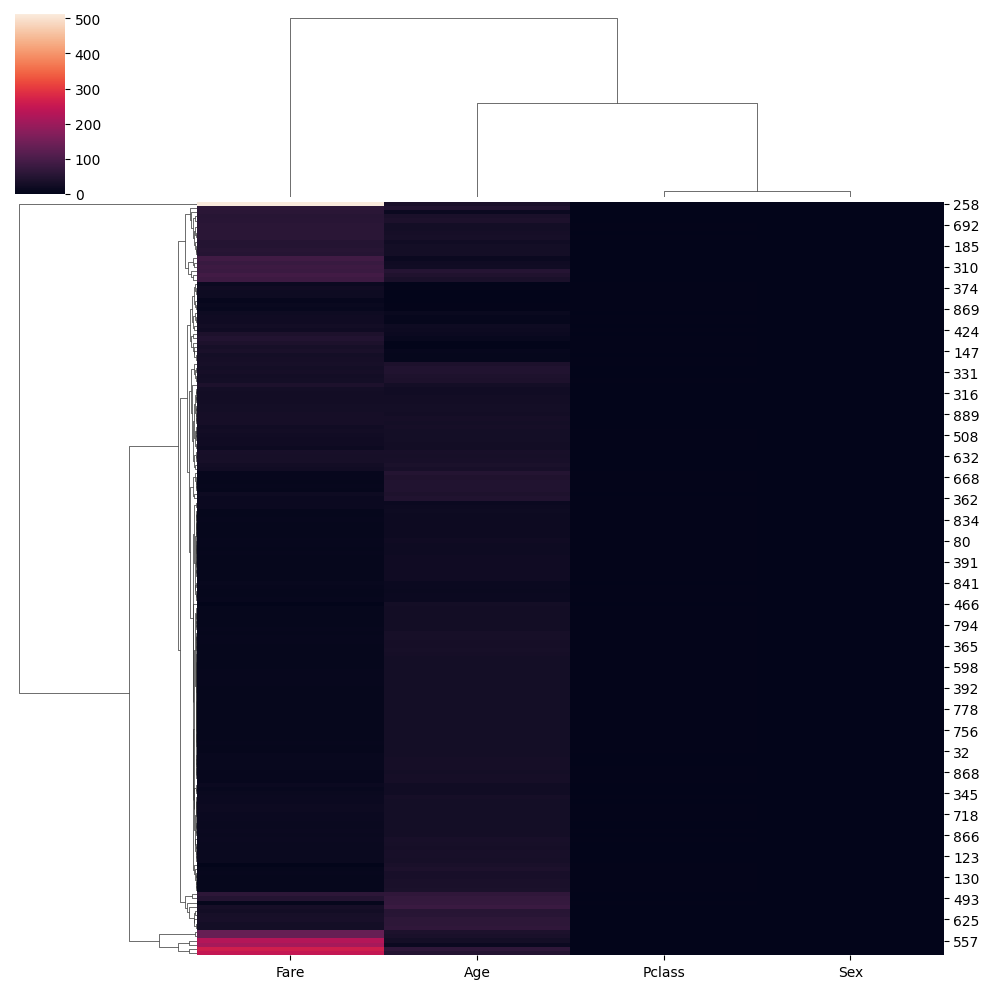

In [117]:
sn.clustermap(X_test)

[Text(0.46484867591424966, 0.9814814814814815, 'x[1] <= 0.5\nentropy = 0.96\nsamples = 712\nvalue = [439, 273]'),
 Text(0.18600252206809584, 0.9444444444444444, 'x[0] <= 2.5\nentropy = 0.805\nsamples = 244\nvalue = [60, 184]'),
 Text(0.32542559899117274, 0.962962962962963, 'True  '),
 Text(0.07566204287515763, 0.9074074074074074, 'x[3] <= 28.856\nentropy = 0.323\nsamples = 136\nvalue = [8, 128]'),
 Text(0.05044136191677175, 0.8703703703703703, 'x[3] <= 28.231\nentropy = 0.51\nsamples = 53\nvalue = [6, 47]'),
 Text(0.0403530895334174, 0.8333333333333334, 'x[2] <= 23.5\nentropy = 0.457\nsamples = 52\nvalue = [5, 47]'),
 Text(0.03026481715006305, 0.7962962962962963, 'entropy = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.05044136191677175, 0.7962962962962963, 'x[2] <= 27.5\nentropy = 0.544\nsamples = 40\nvalue = [5, 35]'),
 Text(0.03026481715006305, 0.7592592592592593, 'x[2] <= 26.0\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]'),
 Text(0.0201765447667087, 0.7222222222222222, 'x[3] <= 13

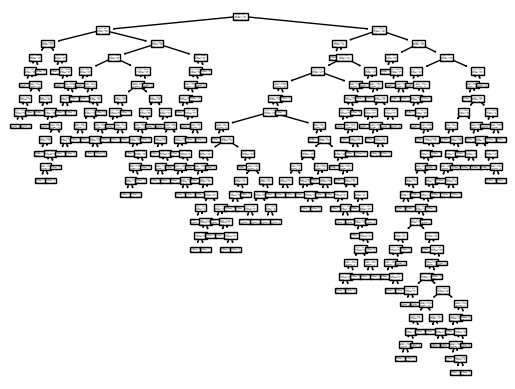

In [ ]:
from sklearn.tree import plot_tree

plot_tree(titanic_model)